In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle



In [5]:
df = pd.read_csv("stds_performance.csv")
df.describe() 


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [6]:
print("----------------------- Checking null values -----------------------")
print (df.isna()) #Checking for null values

print ("----------------------- Counting missing values per column -----------------------")
print(df.isna().sum()) # checking null values in each column

print ("----------------------- Dropping rows with NaN values -----------------------")
new_df = df.dropna() #dropping rows with null values

print("----------------------- verifying whether null values is removed or not -----------------------")
new_df.isna().sum()# checking for null values after removing them

----------------------- Checking null values -----------------------
      StudentID    Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0         False  False   False      False              False            False   
1         False  False   False      False              False            False   
2         False  False   False      False              False            False   
3         False  False   False      False              False            False   
4         False  False   False      False              False            False   
...         ...    ...     ...        ...                ...              ...   
2387      False  False   False      False              False            False   
2388      False  False   False      False              False            False   
2389      False  False   False      False              False            False   
2390      False  False   False      False              False            False   
2391      False  False   False      Fals

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [7]:
# Checking for duplicate rows in the DataFrame 'new_df'
duplicates = new_df.duplicated()  

# Counting the total number of duplicate rows by adding the True values
total_duplicates = duplicates.sum()  

# Displaying the total number of duplicates found
total_duplicates
# Remove duplicates (if any)
new_df = new_df.drop_duplicates()

In [8]:
# Counting total number of columns in the dataframe
total_columns = len(new_df.columns)

# Print total columns
print("Total number of columns:", total_columns)


print("------------------Column Names-----------------")

# Loop through each column name in the dataframe
for column in new_df.columns:
    print(column)  #  this prints column name one by one

Total number of columns: 15
------------------Column Names-----------------
StudentID
Age
Gender
Ethnicity
ParentalEducation
StudyTimeWeekly
Absences
Tutoring
ParentalSupport
Extracurricular
Sports
Music
Volunteering
GPA
GradeClass


In [9]:
# Check current data types
print(new_df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [10]:
# Convert columns to integer type
int_cols = [
    'StudentID', 'Age', 'Gender', 'Ethnicity',
    'ParentalEducation', 'Absences', 'Tutoring',
    'ParentalSupport', 'Extracurricular',
    'Sports', 'Music', 'Volunteering', 'GradeClass'
]

for col in int_cols:
    new_df[col] = new_df[col].astype(int)

# Convert columns to float type
new_df['StudyTimeWeekly'] = new_df['StudyTimeWeekly'].astype(float)
new_df['GPA'] = new_df['GPA'].astype(float)

# Verify updated data types
print(new_df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64
dtype: object


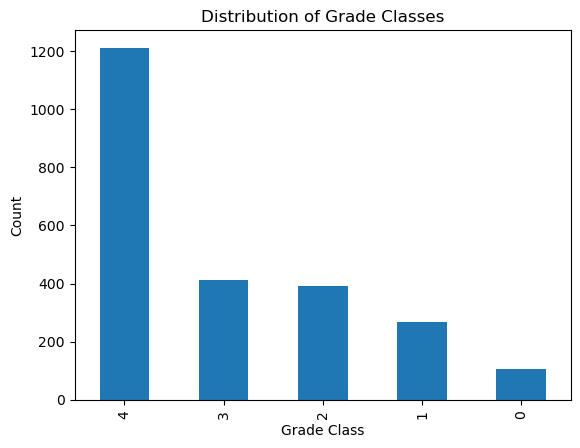

In [11]:
#check distribution of grade class
new_df['GradeClass'].value_counts().plot(kind='bar')
plt.title('Distribution of Grade Classes')
plt.xlabel('Grade Class')
plt.ylabel('Count')
plt.show()

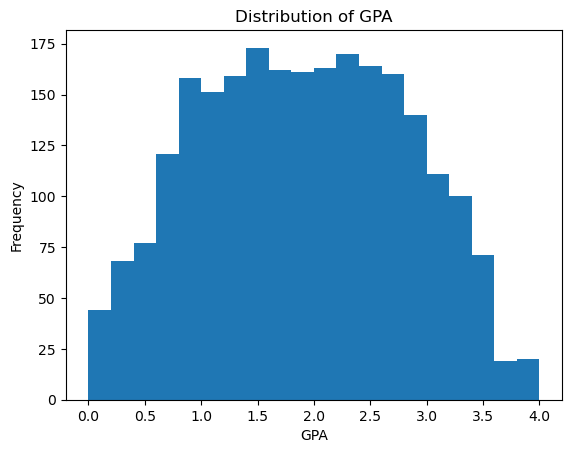

In [12]:
# GPA distribution
plt.hist(new_df['GPA'], bins=20)
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.show()

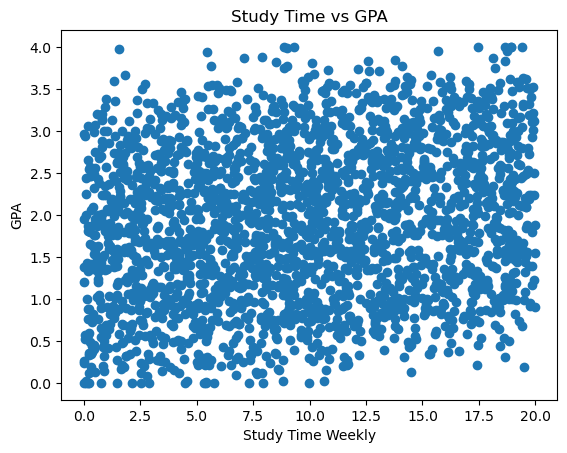

In [12]:
# Study Time VS GPA
plt.scatter(new_df['StudyTimeWeekly'], new_df['GPA'])
plt.title('Study Time vs GPA')
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.show()

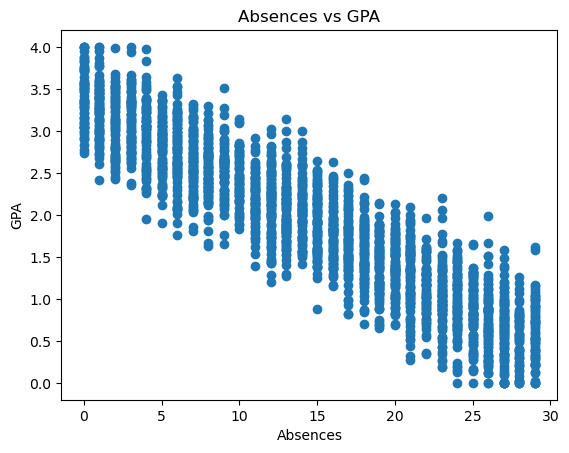

In [13]:
# Absences VS GPA
plt.scatter(new_df['Absences'], new_df['GPA'])
plt.title('Absences vs GPA')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.show()

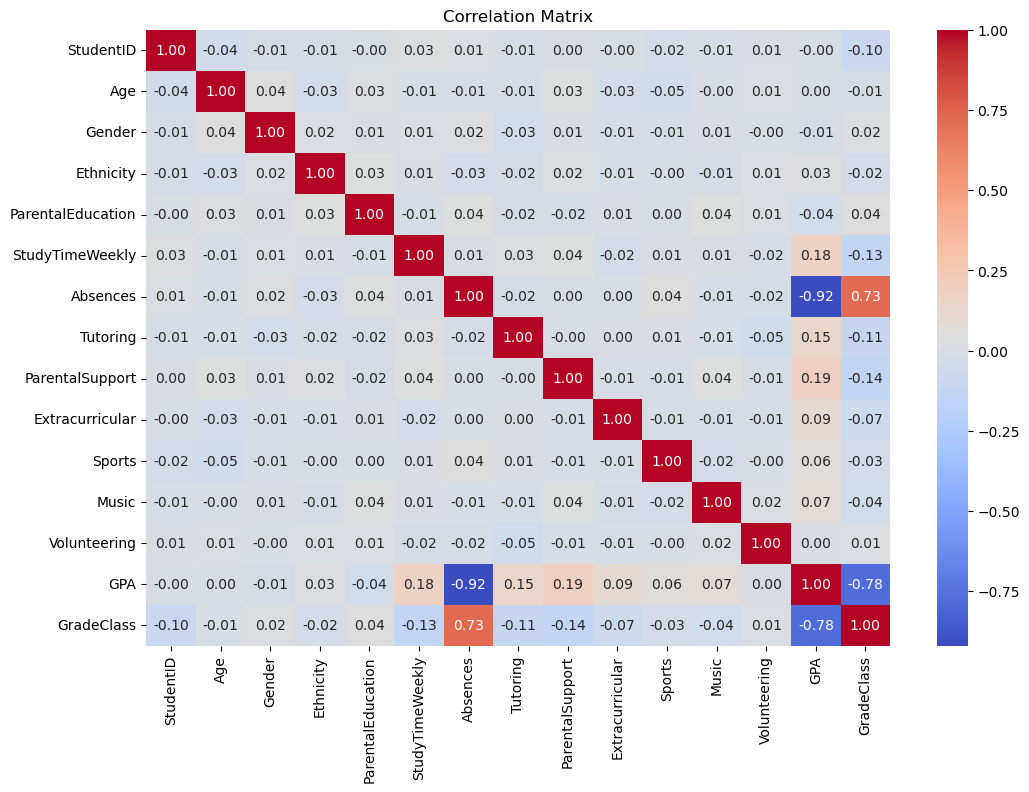

In [13]:
# Corelation Analysis
corr_matrix = new_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

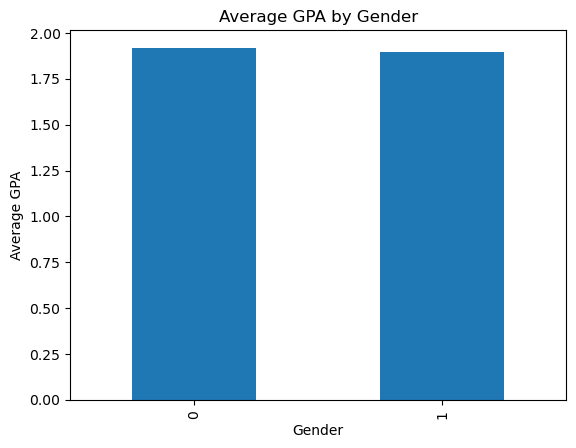

In [16]:
# GPA by Gender
new_df.groupby('Gender')['GPA'].mean().plot(kind='bar')
plt.title('Average GPA by Gender')
plt.xlabel('Gender')
plt.ylabel('Average GPA')
plt.show()

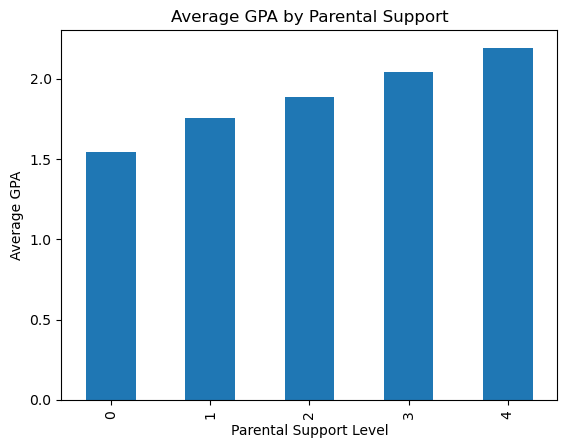

In [17]:
# GPA by parental support
new_df.groupby('ParentalSupport')['GPA'].mean().plot(kind='bar')
plt.title('Average GPA by Parental Support')
plt.xlabel('Parental Support Level')
plt.ylabel('Average GPA')
plt.show()

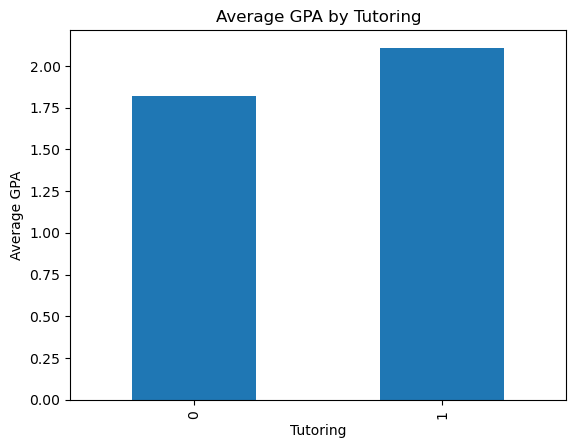

In [19]:
# Effect of tutoring on GPA
new_df.groupby('Tutoring')['GPA'].mean().plot(kind='bar')
plt.title('Average GPA by Tutoring')
plt.xlabel('Tutoring')
plt.ylabel('Average GPA')
plt.show()

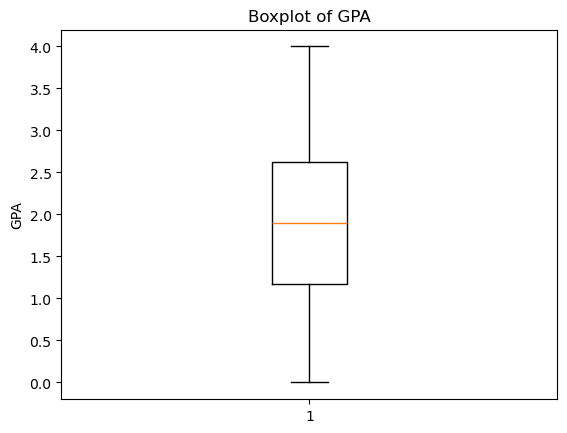

In [20]:
# Outlier Detection
plt.boxplot(new_df['GPA'])
plt.title('Boxplot of GPA')
plt.ylabel('GPA')
plt.show()

# For GPA Prediction

In [ ]:
# Features (X)
X = new_df.drop('GPA', axis=1)

# Target (y)
y = new_df['GPA']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

In [ ]:
# Correlation of all features with GPA
gpa_corr = new_df.corr()['GPA'].sort_values(ascending=False)

print(gpa_corr.drop('GPA'))

In [ ]:
# Correlation visualization
gpa_corr.drop('GPA').plot(kind='bar')
plt.title('Feature Correlation with GPA')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

In [ ]:
# Feature Importance
X = new_df.drop('GPA', axis=1)
y = new_df['GPA']

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

In [ ]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title('Feature Importance for GPA Prediction')
plt.ylabel('Importance Score')
plt.show()

#Feature Selection:
Feature selection was performed to identify the factors that most strongly influence student GPA. Correlation analysis and the Random Forest Regressor feature importance technique were used. Features such as Absences, StudyTimeWeekly, ParentalSupport, Tutoring, and Extracurricular Activities showed significant influence on GPA and were selected for model development

# Train-Test Split

In [ ]:
X = new_df.drop('GPA', axis=1)
y = new_df['GPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions

In [ ]:
y_pred = model.predict(X_test)
#print(y_pred)

# Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

In [ ]:
 lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print(comparison)

# Visualization

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

In [ ]:
with open('gpa_model.pkl', 'rb') as f:
    model = pickle.load(f)